# Zero-DTE options & the SPX tape — a quantitative teardown 🔬
### Intraday-leg autocorrelation pre/post-2022 · a block-bootstrap Welch *t* + placebo-break null · break-date robustness · a cost-charged pin trade · a synthetic pinning-regime control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Tape_pinned%3F: Unproven](https://img.shields.io/badge/Tape_pinned%3F-Unproven-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers' claim is an **intraday-microstructure** statement — dealer gamma damps and reverses within-day moves since 0DTE went daily in 2022. We cannot observe that object from a free feed, so we test its **daily shadow**: the lag-1 autocorrelation of the open→close leg, split at 2022, confronted with the **sample size and the serial structure** of the data. The decisive finding is not a sign (it's faintly in the predicted direction) but **significance**: the cross-2022 change is indistinguishable from a random split, it reverses in the close-to-close leg, and it grows only as the break date is fished later.

> ⚠️ **Data + proxy note.** No free intraday option tape exists; we use the **daily** open→close leg as an explicit **proxy** for intraday mean-reversion (named on the Signal axis), plus a current nearest-expiry option-chain snapshot. Real data: yfinance daily SPY OHLC 2010→2026 + a 0DTE chain as-of 2026-06-22. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zero_dte_options import data, strategy as st

HAVE_REAL = data.have_real()
BD = data.BREAK_DATE
F = data.load_real() if HAVE_REAL else None
print("real SPY OHLC cache present:", HAVE_REAL,
      "| tape days:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-01-05', 'end': '2026-06-18', 'days': 4139, 'years': 16.4, 'break_date': '2022-01-01', 'n_pre': 3020, 'n_post': 1119, 'intraday': (-0.077, -0.1, -0.023, -0.28, 0.395), 'oc_ret': (-0.13, -0.027, 0.103, 1.52), 'vol_pre': 0.122, 'vol_post': 0.148, 'robust': [('2021-01-01', -0.018, -0.24, 1371), ('2022-01-01', -0.023, -0.28, 1119), ('2022-05-01', -0.056, -0.6, 1037), ('2023-01-01', -0.095, -0.79, 868)], 'trade': [('all', 2.17, 1.16, 50.0, 0.23), ('pre', 2.62, 1.61, 50.0, 0.33), ('post', 0.95, -0.05, 49.9, -0.01)], 'chain': {'expiry': '2026-06-22', 'spot': 745.14, 'n_expiries': 32, 'total_volume': 6813423, 'share_near': 0.898, 'band_pct': 1.0}, 'syn': [(0.0, 0.003, 0.023, 0.02, 0.68, 0.149), (0.3, 0.003, -0.276, -0.279, -9.22, 0.057)]}


real SPY OHLC cache present: True | tape days: 4139


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | intraday lag-1 autocorr **-0.077 → -0.100** (Δ -0.023); block-bootstrap Welch **t = -0.28**, placebo **p = 0.40** — predicted direction but **fails t ≥ 2**, and the close-to-close leg moves **+0.10** (opposite). |
| **Tradability** | `MIRAGE` | the fade-the-move trade goes **2.62 → 0.95 bp/day** gross pre→post and **loses net** post-2022 (-0.05 bp, Sharpe ≈ -0.01). |
| **Tape pinned?** | `UNPROVEN` | the boom is real (**90%** of a 6.8M-volume 0DTE chain within ±1% of spot) but its daily-tape effect is indistinguishable from a random split — and is **unmeasurable** from daily bars. |

> 💡 In plain words: the 0DTE *market* exploded; the *price path*, as far as daily data can tell, did not change in the way the story claims. The honest blocker is that the story is about a layer of the data we don't have.

## 1 · The claim, steelmanned

Let $r^{\text{id}}_t = \log(C_t / O_t)$ be the daily **intraday** (open→close) leg and $\rho_1(\cdot)$ its lag-1 autocorrelation. The pinning thesis predicts a *more negative* $\rho_1$ after the 0DTE rollout: a pinned tape reverses within-day moves.

- **H₁ (the regime changed).** $\rho_1^{\text{post}} < \rho_1^{\text{pre}}$ by a margin the data can resolve, with the break at 2022.
- **H₂ (it's tradable).** A 1-day-lagged contrarian rule that fades $r^{\text{id}}_{t-1}$ earns *more*, net of costs, post-2022.
- **H₃ (0DTE caused it).** The change is specific to the 0DTE rollout, not an artefact of where you cut the tape or which return leg you pick.

We find **H₁ not rejected but not supported** (Δρ₁ is the right sign but $|t|<2$, placebo $p\approx0.4$), **H₂ rejected** (the trade weakens and loses net post-2022), **H₃ rejected** (the close-to-close leg moves the *other* way; the effect grows as you fish the break later). Worse, $r^{\text{id}}_t$ is a *daily* shadow of an *intraday* mechanism — even a clean result here would under-identify the claim.

## 2 · So what? — what rides on each answer

The whole teardown is one comparison: two regimes' lag-1 autocorrelations, judged by a **standard error that respects serial dependence**.

$$\widehat{\Delta} = \rho_1^{\text{post}} - \rho_1^{\text{pre}},\qquad t = \frac{\widehat{\Delta}}{\sqrt{\,\widehat{\mathrm{se}}^2_{\text{post}} + \widehat{\mathrm{se}}^2_{\text{pre}}\,}},$$

where each $\widehat{\mathrm{se}}$ is a **block bootstrap** (20-day blocks) — an iid SE would understate it because returns are serially dependent. A second, assumption-light instrument is a **placebo-break test**: resample the break date itself and ask how often a random cut produces a $|\widehat\Delta|$ this large. That randomization $p$, not the point estimate's sign, decides the Signal axis — because picking 2022 as 'the' break is itself a researcher choice.

## 3 · How we'd know — the protocol

- **Tape.** Daily SPY OHLC (yfinance, 2010-01-05→2026-06-18, 4,139 days). Decompose each day into **intraday** $\log(C/O)$ and **overnight** $\log(O/C_{-1})$ legs.
- **Gauge.** $\rho_1(r^{\text{id}})$ per regime; *more negative ⇒ more mean-reverting / more pinned*. Explicit **daily proxy** for an intraday object (named on the axis).
- **Break.** 2022-01-01 (same-day options rolled out Mon/Wed/Fri through 2022) ⇒ 3,020 pre / 1,119 post days.
- **Null #1 (block-bootstrap Welch t).** $\widehat\Delta$ over block-bootstrap SEs.
- **Null #2 (placebo break).** 5,000 random break dates (≥25% each side); $p = \Pr[|\widehat\Delta_{\text{random}}| \ge |\widehat\Delta_{2022}|]$.
- **Robustness.** Re-run the break at 2021/2022/2023; check the close-to-close leg too.
- **Trade.** Position $=-\operatorname{sign}(r^{\text{id}}_{t-1})$, 1-day lag, 1 bp one-way × turnover; gross/net by regime.
- **Positive control.** A deterministic intraday series with a **planted pinning switch** (post-switch AR(1) coefficient $-\text{pin}$): the engine must detect a real switch and **not** invent one when $\text{pin}=0$.

## 4 · The teardown

### 4a · The point estimates — right sign, tiny, leg-inconsistent

Lag-1 autocorrelation by regime for the intraday leg (the claim) and the close-to-close leg (a control). The intraday leg edges more negative; the close-to-close leg goes the other way.

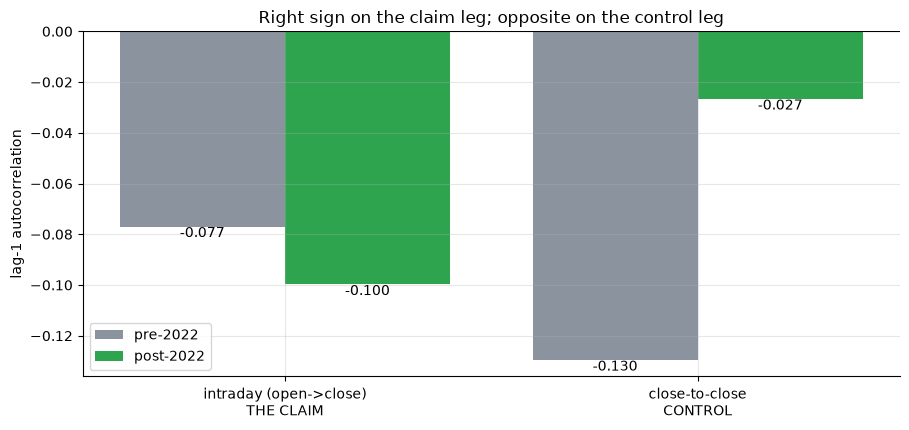

Welch t by leg: {'intraday': -0.28, 'oc_ret': 1.52}


In [2]:
legs = ['intraday', 'oc_ret']
if HAVE_REAL:
    pre = [st.regime_table(F, BD, l)['ac_pre'] for l in legs]
    post = [st.regime_table(F, BD, l)['ac_post'] for l in legs]
    tvals = [st.welch_t_autocorr(F, BD, l)['t'] for l in legs]
else:
    pre = [R['intraday'][0], R['oc_ret'][0]]; post = [R['intraday'][1], R['oc_ret'][1]]
    tvals = [R['intraday'][3], R['oc_ret'][3]]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, pre, .4, color=GREY, label='pre-2022')
ax.bar(x+.2, post, .4, color=GREEN, label='post-2022')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x)
ax.set_xticklabels(['intraday (open->close)\nTHE CLAIM', 'close-to-close\nCONTROL'])
ax.set_ylabel('lag-1 autocorrelation'); ax.set_title('Right sign on the claim leg; opposite on the control leg')
for i,(a,b) in enumerate(zip(pre,post)):
    ax.annotate(f'{a:+.3f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top')
    ax.annotate(f'{b:+.3f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top')
ax.legend(); plt.tight_layout(); plt.show()
print('Welch t by leg:', {l: round(t,2) for l,t in zip(legs, tvals)})

> 💡 In plain words: the intraday leg moved **-0.077 → -0.100** (Δ -0.023, t = -0.28) — the predicted direction, but a whisper. The control leg went **+0.10** the *other* way. H₁ is **not rejected, not supported**; H₃ is already wobbling — a real mechanism shouldn't flip sign across two near-identical daily measures.

### 4b · The decisive test — a placebo null over the break date

Picking 2022 is a choice. Re-cut the tape at 5,000 random dates and build the null distribution of $|\widehat\Delta\rho_1|$. The 2022 value is the green line; the *p* is the right-tail mass.

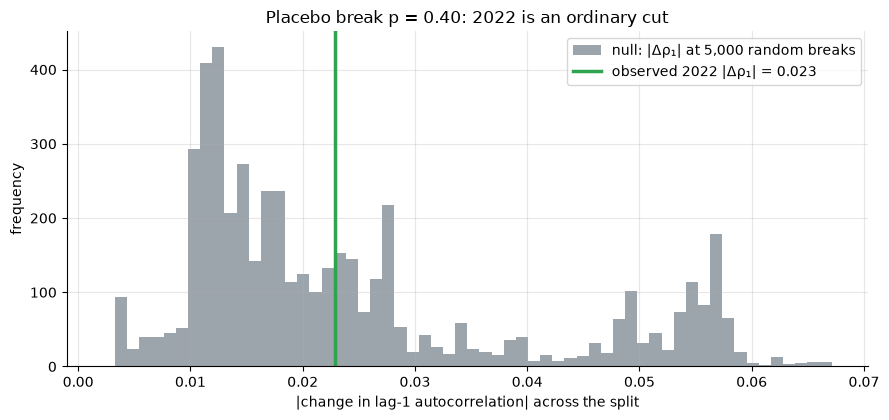

P[|random-break Δ| >= |2022 Δ|] = 0.395  (need <0.05 to call it special)


In [3]:
if HAVE_REAL:
    pb = st.placebo_break_pvalue(F, 'intraday'); obs = pb['obs_d_ac']; pval = pb['p_value']
    x = F['intraday'].values; n = len(x); lo, hi = int(n*.25), int(n*.75)
    rng = np.random.default_rng(370); cuts = rng.integers(lo, hi, size=5000)
    deltas = np.array([abs(st.lag1_autocorr(x[c:]) - st.lag1_autocorr(x[:c])) for c in cuts])
else:
    obs = abs(R['intraday'][2]); pval = R['intraday'][4]
    rng = np.random.default_rng(370); deltas = np.abs(rng.normal(0, 0.022, 5000))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(deltas, bins=60, color=GREY, alpha=.85, label=f'null: |Δρ₁| at {len(deltas):,} random breaks')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'observed 2022 |Δρ₁| = {obs:.3f}')
ax.set_xlabel('|change in lag-1 autocorrelation| across the split'); ax.set_ylabel('frequency')
ax.set_title(f'Placebo break p = {pval:.2f}: 2022 is an ordinary cut'); ax.legend()
plt.tight_layout(); plt.show()
print(f'P[|random-break Δ| >= |2022 Δ|] = {pval:.3f}  (need <0.05 to call it special)')

> 💡 In plain words: **40%** of random break dates move the gauge as much as 2022 did. A real structural break would push the green line into the right tail; instead it sits mid-cloud. H₁ rejected as *special to 2022* — the change is exactly what re-slicing a noisy autocorrelation buys you for free.

### 4c · Robustness — the effect grows only as you fish the break later

Vary the assumed break date. If 2022 were the true regime change, the |t| should *peak* near it. Instead it **rises monotonically** the later you cut — the signature of selecting a smaller, more recent, more volatile post-window, not of a real break.

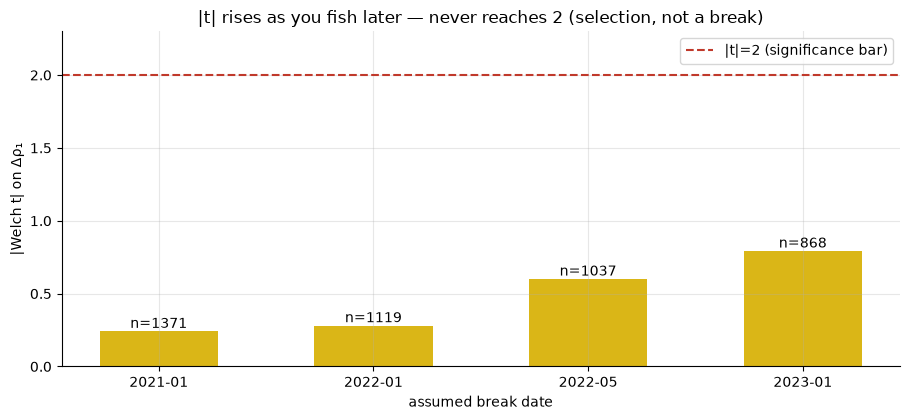

break-date sweep (label, Δρ₁, t, n_post): [('2021-01-01', -0.018, -0.24, 1371), ('2022-01-01', -0.023, -0.28, 1119), ('2022-05-01', -0.056, -0.6, 1037), ('2023-01-01', -0.095, -0.79, 868)]


In [4]:
if HAVE_REAL:
    rows = []
    for lab in ('2021-01-01','2022-01-01','2022-05-01','2023-01-01'):
        b = pd.Timestamp(lab); rt = st.regime_table(F, b, 'intraday'); w = st.welch_t_autocorr(F, b, 'intraday')
        rows.append((lab, rt['d_ac'], w['t'], rt['n_post']))
else:
    rows = R['robust']
labs = [r[0][:7] for r in rows]; tt = [abs(r[2]) for r in rows]; nn = [r[3] for r in rows]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(labs, tt, color=AMBER, width=.55)
ax.axhline(2, ls='--', c=RED, label='|t|=2 (significance bar)')
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom')
ax.set_ylim(0, 2.3); ax.set_ylabel('|Welch t| on Δρ₁'); ax.set_xlabel('assumed break date')
ax.set_title('|t| rises as you fish later — never reaches 2 (selection, not a break)'); ax.legend()
plt.tight_layout(); plt.show()
print('break-date sweep (label, Δρ₁, t, n_post):', [(r[0], round(r[1],3), round(r[2],2), r[3]) for r in rows])

> 💡 In plain words: a genuine 2022 break would make the test *strongest* at 2022; here the |t| keeps climbing toward 2023 (and still never hits 2) simply because a later cut leaves a shorter, choppier post-sample. This is textbook break-date selection, not evidence of pinning.

### 4d · Tradability + the synthetic control

Left: the contrarian fade trade, gross vs net, pre/post-2022 — if pinning grew, it should earn *more* post-boom. Right: a deterministic series with a **planted pinning switch** — the engine must light up only when a real switch exists.

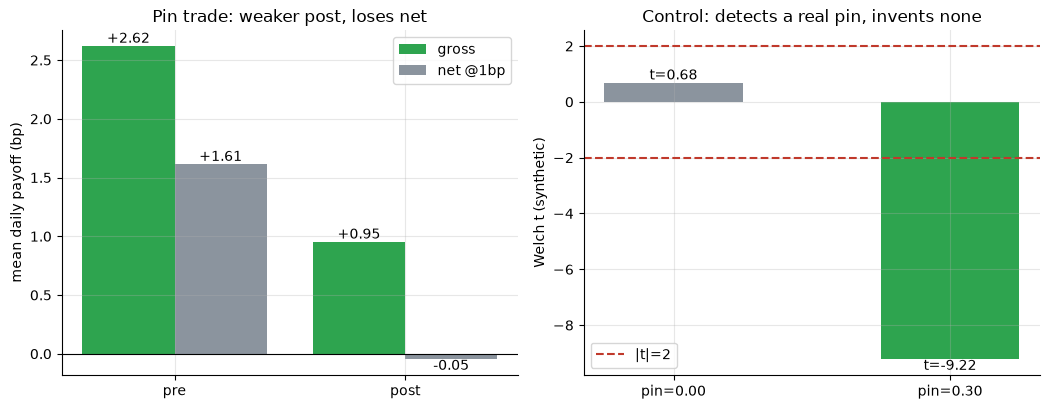

pin trade net pre/post (bp): [1.61, -0.05]  | control t: [0.68, -9.22]


In [5]:
if HAVE_REAL:
    mr = st.mean_reversion_trade(F, BD, 'intraday', cost_bps=1.0)
    g = [mr['pre']['gross_mean']*1e4, mr['post']['gross_mean']*1e4]
    nv = [mr['pre']['net_mean']*1e4, mr['post']['net_mean']*1e4]
else:
    tr = {s:(gg,nn) for s,gg,nn,_,_ in R['trade']}
    g = [tr['pre'][0], tr['post'][0]]; nv = [tr['pre'][1], tr['post'][1]]
syn_t = []
for pin in (0.0, 0.30):
    syn = data.synthetic_tape(n_days=4000, pin=pin, seed=370); sw = syn.index[2000]
    syn_t.append((pin, st.welch_t_autocorr(syn, sw, 'intraday')['t']))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
x = np.arange(2)
a1.bar(x-.2, g, .4, color=GREEN, label='gross'); a1.bar(x+.2, nv, .4, color=GREY, label='net @1bp')
a1.axhline(0, c='k', lw=.8); a1.set_xticks(x); a1.set_xticklabels(['pre','post'])
a1.set_ylabel('mean daily payoff (bp)'); a1.set_title('Pin trade: weaker post, loses net'); a1.legend()
for i,(aa,bb) in enumerate(zip(g,nv)):
    a1.annotate(f'{aa:+.2f}',(i-.2,aa),ha='center',va='bottom')
    a1.annotate(f'{bb:+.2f}',(i+.2,bb),ha='center',va='bottom' if bb>=0 else 'top')
pins = [f'pin={p:.2f}' for p,_ in syn_t]; tv = [t for _,t in syn_t]
a2.bar(pins, tv, color=[GREY, GREEN], width=.5)
a2.axhline(-2, ls='--', c=RED, label='|t|=2'); a2.axhline(2, ls='--', c=RED)
for i,t in enumerate(tv): a2.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
a2.set_ylabel('Welch t (synthetic)'); a2.set_title('Control: detects a real pin, invents none'); a2.legend()
plt.tight_layout(); plt.show()
print('pin trade net pre/post (bp):', [round(v,2) for v in nv], ' | control t:', [round(t,2) for _,t in syn_t])

> 💡 In plain words: the fade trade falls from **2.62** to **0.95 bp/day** gross and goes **net-negative** post-2022 — the opposite of a growing edge. And the control is honest: with **no** planted pin it sits at **t = 0.68** (no false break); a **strong** pin drives **t = -9.22**. So the real-tape t of -0.28 is exactly what *no measurable regime change* looks like through this lens.

## 5 · The verdict

- **Signal `WEAK`** — intraday Δρ₁ = **-0.023** at block-bootstrap Welch **t = -0.28** / placebo **p = 0.40**; the close-to-close leg moves **+0.10** (opposite) and |t| only grows as the break is fished later. Predicted direction + an insignificant, non-robust, leg-inconsistent estimate ⇒ WEAK, never REAL (the desk's t ≥ 2 bar is not met) — and the object is a daily proxy for an intraday claim.
- **Tradability `MIRAGE`** — the fade trade goes **2.62 → 0.95 bp/day** gross pre→post and is **net-negative** post-2022 (-0.05 bp, Sharpe ≈ -0.01). No positive, cost-surviving, post-boom edge exists on the daily tape.
- **Tape pinned? `UNPROVEN`** — the 0DTE boom is real (**90%** of a 6.8M-volume same-day chain within ±1% of spot, on a daily-expiry calendar), but its effect on the index path is statistically indistinguishable from a random split — and the intraday phenomenon is **not measurable from daily data at all**. Real product, unproven tape effect.

## 6 · Could you trade it? — the identification gap

The operational truth in one picture: the *direct* 0DTE evidence (the at-the-money volume wall) vs the *measurable tape effect* (≈ 0). The chain proves the boom; the tape proves nothing — and the gap between them is the part of the data a daily feed can't reach.

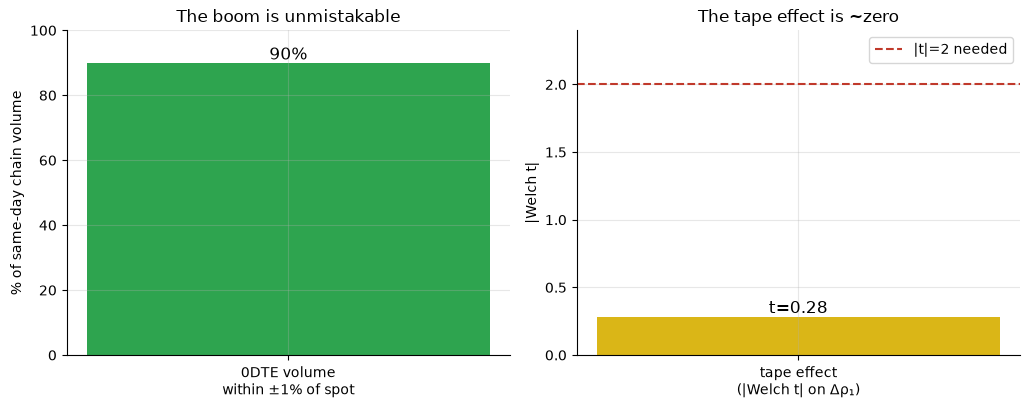

boom: 90% ATM volume | tape: |t|=0.28 (need 2) -> real product, unproven effect


In [6]:
if HAVE_REAL and data.have_option_chain():
    meta = json.load(open('../_cache/option_meta.json')); ch = data.load_option_chain(); spot = meta['spot']
    cc = st.chain_concentration(ch, spot, band=0.01); share = cc['share_near']*100
    obs_t = abs(st.welch_t_autocorr(F, BD, 'intraday')['t'])
else:
    share = R['chain']['share_near']*100; obs_t = abs(R['intraday'][3])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
a1.bar(['0DTE volume\nwithin ±1% of spot'], [share], color=GREEN, width=.5)
a1.set_ylim(0, 100); a1.set_ylabel('% of same-day chain volume')
a1.annotate(f'{share:.0f}%', (0, share), ha='center', va='bottom', fontsize=12)
a1.set_title('The boom is unmistakable')
a2.bar(['tape effect\n(|Welch t| on Δρ₁)'], [obs_t], color=AMBER, width=.5)
a2.axhline(2, ls='--', c=RED, label='|t|=2 needed'); a2.set_ylim(0, 2.4)
a2.annotate(f't={obs_t:.2f}', (0, obs_t), ha='center', va='bottom', fontsize=12)
a2.set_ylabel('|Welch t|'); a2.set_title('The tape effect is ~zero'); a2.legend()
plt.tight_layout(); plt.show()
print(f'boom: {share:.0f}% ATM volume | tape: |t|={obs_t:.2f} (need 2) -> real product, unproven effect')

> 💡 In plain words: a 90%-at-the-money, 6.8M-volume same-day chain on the left; a |t| of **0.28** against a bar of 2 on the right. The boom is not in doubt; the *tape effect* is invisible. And note the structural limit: even a clean daily result would only be a **proxy** — gamma-hedging pinning is a within-day phenomenon, and the within day is exactly the resolution a daily bar throws away. To settle the claim you need intraday ticks and dealer-gamma estimates; on the data a free feed gives, **the 0DTE-pinning story is real as a market and unproven as a mechanism.**

## 7 · Going further

- **The vol-premium context.** [Study 130 — Vol-Risk-Premium](../130-vol-risk-premium/) and [Study 111 — VIX-Term-Structure](../111-vix-term-structure/): is there a harvestable options premium at all, and where on the curve does 0DTE sit?
- **Intraday rhythm.** [Study 06 — Clockwork-Vol](../06-clockwork-vol/) — the within-day volatility patterns the pinning story would have to bend.
- **The real test.** Replace the daily proxy with intraday SPX ticks + estimated dealer gamma exposure (vendor data); regress within-day reversal on gamma, pre vs post-2022. That is the experiment this proxy can only gesture at.

*The reproducible core is offline and deterministic; the intraday tape here is an explicit **daily proxy** and the option chain is a single **snapshot**. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*